# MIRI and NIRCam RGB images on one rotated sky grid

This notebook displays the two Photoshop JPEGs using their matching FITS WCS files. The field centre, width, height, and position angle are all collected in the next cell. The MIRI white canvas is replaced only where its near-white pixels connect to the JPEG edge, so bright stars are retained.

In [26]:
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from matplotlib.image import imread
from matplotlib.lines import Line2D
from PIL import Image
from scipy.ndimage import binary_fill_holes, binary_propagation, map_coordinates

# The NIRCam JPEG is large but is a trusted local product.
Image.MAX_IMAGE_PIXELS = None

# Input files
DATA_DIR = Path('/Users/abarnes/Library/CloudStorage/Dropbox/Data/Galactic/JWST/cloud_h/jwst/fits/nanfilled/reprojected')
MIRI_JPEG = DATA_DIR / 'miri_photoshop.jpeg'
MIRI_WCS_FITS = DATA_DIR / 'jw07230-o002_t003_miri_f770w_i2d_nanfilled_reprojected.fits'
NIRCAM_JPEG = DATA_DIR / 'nircam_photoshop.jpeg'
NIRCAM_WCS_FITS = DATA_DIR / 'jw07230-o004_t003_nircam_clear-f356w_i2d_nanfilled_reprojected.fits'

# # Display controls: change these four values to choose a new sky cutout.
# DISPLAY_RA = '18h57m08.0128509137s'
# DISPLAY_DEC = '02d10m04.9524657528s'
# DISPLAY_WIDTH_ARCMIN = 2.7
# DISPLAY_HEIGHT_ARCMIN = 6.0
# DISPLAY_PA_DEG = -10  # Position angle of the horizontal plot axis, east of north.

# # Display controls: change these four values to choose a new sky cutout.
# DISPLAY_RA = '18h57m06.8054861384s'
# DISPLAY_DEC = '2d10m06.0169509317s'
# DISPLAY_WIDTH_ARCMIN = 106.7320496730/60
# DISPLAY_HEIGHT_ARCMIN = 4.8571849073
# DISPLAY_PA_DEG = 354.80557109226515 - 360 # Position angle of the horizontal plot axis, east of north.

# Display controls: change these four values to choose a new sky cutout.
DISPLAY_RA = '18h57m06.9897195423s'
DISPLAY_DEC = '2d10m15.3794463101s'
DISPLAY_WIDTH_ARCMIN = 3.1892713314
DISPLAY_HEIGHT_ARCMIN = 6.3763691658
DISPLAY_PA_DEG = 341.5270170076544 - 360 # Position angle of the horizontal plot axis, east of north.

# Put the long supplied dimension across the page, keeping the mosaic horizontal.
PLOT_WIDTH_ARCMIN = DISPLAY_HEIGHT_ARCMIN
PLOT_HEIGHT_ARCMIN = DISPLAY_WIDTH_ARCMIN

# Keep this at the MIRI pixel scale. It controls the resolution of both displayed panels.
# The NIRCam JPEG is resampled onto this same grid for a direct visual comparison.
OUTPUT_FILE = "./../plots/rgb_"
MIRI_WHITE_THRESHOLD = 245  # JPEG values above this are treated as white canvas only if edge-connected.

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in" 

In [27]:
# Read both RGB JPEGs and their matching celestial WCS files.
# JPEG row 0 is the top of the image, whereas FITS/WCS y=0 is the bottom.
# Flip each JPEG vertically before associating its pixels with the FITS WCS.
miri_rgb = np.flipud(imread(MIRI_JPEG)[..., :3]).copy()
nircam_rgb = np.flipud(imread(NIRCAM_JPEG)[..., :3])

with fits.open(MIRI_WCS_FITS, memmap=True) as hdul:
    miri_shape = hdul[1].data.shape
    miri_wcs = WCS(hdul[1].header).celestial

with fits.open(NIRCAM_WCS_FITS, memmap=True) as hdul:
    nircam_shape = hdul[1].data.shape
    nircam_wcs = WCS(hdul[1].header).celestial

if miri_rgb.shape[:2] != miri_shape:
    raise ValueError(f'MIRI JPEG shape {miri_rgb.shape[:2]} does not match FITS shape {miri_shape}.')
if nircam_rgb.shape[:2] != nircam_shape:
    raise ValueError(f'NIRCam JPEG shape {nircam_rgb.shape[:2]} does not match FITS shape {nircam_shape}.')

# The white background is a connected JPEG canvas, not part of the MIRI mosaic.
miri_white = np.all(miri_rgb >= MIRI_WHITE_THRESHOLD, axis=2)
miri_edge = np.zeros(miri_shape, dtype=bool)
miri_edge[[0, -1], :] = True
miri_edge[:, [0, -1]] = True
miri_background = binary_propagation(miri_edge & miri_white, mask=miri_white)
miri_rgb[miri_background] = 0

print(f'MIRI JPEG/FITS: {miri_rgb.shape[1]} x {miri_rgb.shape[0]} pixels')
print(f'NIRCam JPEG/FITS: {nircam_rgb.shape[1]} x {nircam_rgb.shape[0]} pixels')


MIRI JPEG/FITS: 1364 x 3185 pixels
NIRCam JPEG/FITS: 8506 x 12435 pixels


Set DATE-AVG to '2026-04-20T19:13:48.581' from MJD-AVG.
Set DATE-END to '2026-04-20T20:21:51.119' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -19.247298 from OBSGEO-[XYZ].
Set OBSGEO-H to 1505726645.939 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2026-05-12T02:20:38.473' from MJD-AVG.
Set DATE-END to '2026-05-12T02:31:06.605' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.337902 from OBSGEO-[XYZ].
Set OBSGEO-H to 1674445997.841 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [28]:
# Build one rotated output WCS centred on the requested coordinates.
# Its x axis has the requested position angle, so both panels have the same orientation.
display_center = SkyCoord(DISPLAY_RA, DISPLAY_DEC, frame='icrs')
miri_pixel_scale = (np.mean(proj_plane_pixel_scales(miri_wcs)) * u.deg).to_value(u.arcsec)
display_width_pixels = int(np.ceil(PLOT_WIDTH_ARCMIN * 60 / miri_pixel_scale))
display_height_pixels = int(np.ceil(PLOT_HEIGHT_ARCMIN * 60 / miri_pixel_scale))

# In the usual RA-left, Dec-up WCS convention, this rotation puts the requested
# on-sky position angle along the displayed horizontal axis.
wcs_rotation_deg = DISPLAY_PA_DEG + 90
wcs_rotation_rad = np.deg2rad(wcs_rotation_deg)
rotation_matrix = np.array([
    [np.cos(wcs_rotation_rad), -np.sin(wcs_rotation_rad)],
    [np.sin(wcs_rotation_rad),  np.cos(wcs_rotation_rad)],
])

display_wcs = WCS(naxis=2)
display_wcs.wcs.ctype = ['RA---TAN', 'DEC--TAN']
display_wcs.wcs.cunit = ['deg', 'deg']
display_wcs.wcs.crval = [display_center.ra.deg, display_center.dec.deg]
display_wcs.wcs.crpix = [(display_width_pixels + 1) / 2, (display_height_pixels + 1) / 2]
display_wcs.wcs.cdelt = [miri_pixel_scale / 3600, miri_pixel_scale / 3600]
display_wcs.wcs.pc = np.array([[-1, 0], [0, 1]]) @ rotation_matrix
display_wcs.wcs.set()

print(f'Display grid: {display_width_pixels} x {display_height_pixels} pixels')
print(f'MIRI display pixel scale: {miri_pixel_scale:.4f} arcsec/pixel')


Display grid: 3449 x 1726 pixels
MIRI display pixel scale: 0.1109 arcsec/pixel


In [ ]:
# Make world coordinates for each output pixel, then locate those pixels in MIRI.
display_y, display_x = np.mgrid[0:display_height_pixels, 0:display_width_pixels]
ra, dec = display_wcs.pixel_to_world_values(display_x, display_y)
miri_x, miri_y = miri_wcs.world_to_pixel_values(ra, dec)

display_miri = np.empty((display_height_pixels, display_width_pixels, 3), dtype=miri_rgb.dtype)
for channel in range(3):
    display_miri[..., channel] = map_coordinates(
        miri_rgb[..., channel], [miri_y, miri_x], order=1, mode='constant', cval=0
    )


In [ ]:
# Sample the NIRCam JPEG onto exactly the same output WCS and pixel grid.
nircam_x, nircam_y = nircam_wcs.world_to_pixel_values(ra, dec)

display_nircam = np.empty((display_height_pixels, display_width_pixels, 3), dtype=nircam_rgb.dtype)
for channel in range(3):
    display_nircam[..., channel] = map_coordinates(
        nircam_rgb[..., channel], [nircam_y, nircam_x], order=1, mode='constant', cval=0
    )

# Sample the finite-data footprints from the FITS files onto the display grid.
# NaNs outside each observed mosaic become False; valid science pixels become True.
with fits.open(MIRI_WCS_FITS, memmap=True) as hdul:
    sampled_miri_data = map_coordinates(
        hdul[1].data, [miri_y, miri_x], order=0, mode='constant', cval=np.nan, prefilter=False
    )
display_miri_fov = np.isfinite(sampled_miri_data)

with fits.open(NIRCAM_WCS_FITS, memmap=True) as hdul:
    sampled_nircam_data = map_coordinates(
        hdul[1].data, [nircam_y, nircam_x], order=0, mode='constant', cval=np.nan, prefilter=False
    )
display_nircam_fov = np.isfinite(sampled_nircam_data)

# Remove tiny enclosed NaN holes so they do not produce internal contour loops.
# binary_fill_holes leaves the edge-connected area outside each FOV unchanged.
display_miri_fov = binary_fill_holes(display_miri_fov)
display_nircam_fov = binary_fill_holes(display_nircam_fov)

# Black out Photoshop/JPEG pixels beyond each instrument's measured FITS footprint.
display_miri[~display_miri_fov] = 0
display_nircam[~display_nircam_fov] = 0


AttributeError: 'Figure' object has no attribute 'close'

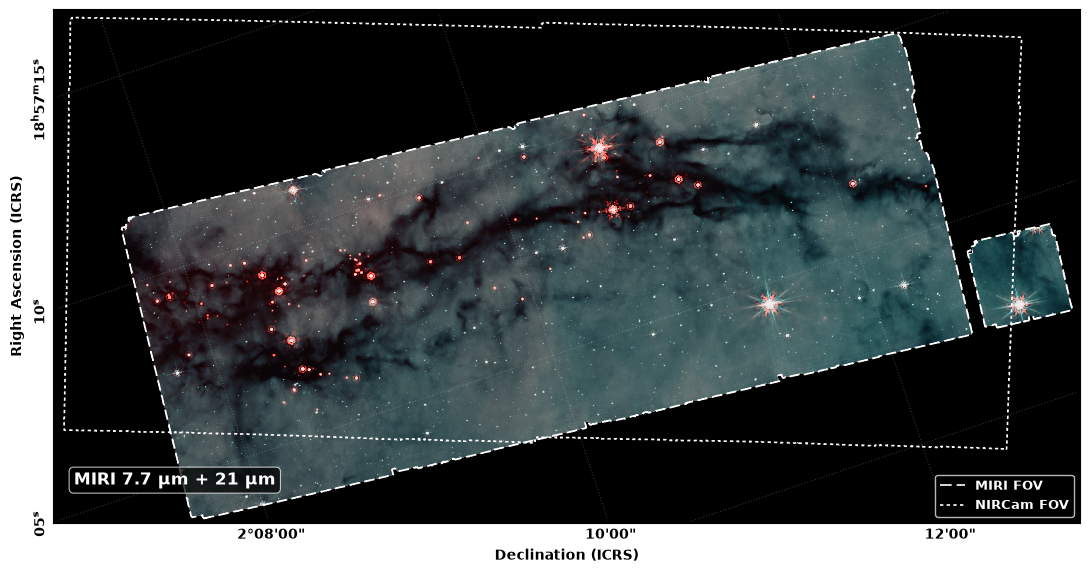

In [ ]:
# Plot both JPEGs with the same coordinates, orientation, and displayed sky region.

fov_legend = [
    Line2D([0], [0], color='white', linewidth=1.2, linestyle=(0, (7, 3)), label='MIRI FOV'),
    Line2D([0], [0], color='white', linewidth=1.2, linestyle=(0, (2, 2)), label='NIRCam FOV'),
]

for interpolation in ['nearest', 'bilinear', 'bicubic']:

    for panel, (image, title, file_prefix) in enumerate([
        (display_miri, 'MIRI 7.7 μm + 21 μm', 'miri'),
        (display_nircam, 'NIRCam 3.56 μm + 4.05 μm + 4.70 μm', 'nircam'),
    ], start=1):

        fig = plt.figure(figsize=(11, 8))

        ax = fig.add_subplot(1, 1, 1, projection=display_wcs)
        ax.set_facecolor('black')
        ax.imshow(image, origin='lower', interpolation=interpolation)
        ax.contour(
            display_miri_fov.astype(float), levels=[0.5], colors='white',
            linewidths=1.2, linestyles=[(0, (7, 3))], origin='lower',
        )
        ax.contour(
            display_nircam_fov.astype(float), levels=[0.5], colors='white',
            linewidths=1.2, linestyles=[(0, (2, 2))], origin='lower',
        )
        ax.coords.grid(color='white', alpha=0.45, linestyle=':')
        ax.coords[0].set_axislabel('Right Ascension (ICRS)')
        ax.coords[1].set_axislabel('Declination (ICRS)')
        ax.coords[0].set_major_formatter('hh:mm:ss')
        ax.coords[1].set_major_formatter('dd:mm:ss')
        ax.coords[0].set_ticklabel(rotation=90, ha='left', va='center')

        ax.text(0.02, 0.1, title, transform=ax.transAxes, ha='left', va='top', fontsize=12,
        fontweight='bold', color='white',
            bbox=dict(
                boxstyle='round,pad=0.28',
                facecolor='black',
                edgecolor='white',
                linewidth=0.8,
                alpha=0.72),
            )

        ax.legend(
            handles=fov_legend, loc='lower right', facecolor='black', edgecolor='white',
            framealpha=0.72, labelcolor='white', fontsize=9,
        )

        ax.grid(color='white', alpha=0.2, linestyle=':')
        
        fig.tight_layout()
        fig.savefig(OUTPUT_FILE+f"{file_prefix}_{interpolation}.pdf", dpi=300, bbox_inches='tight')
        plt.close("all")
        print(f'Saved {OUTPUT_FILE}{file_prefix}_{interpolation}.pdf')